In [3]:
# DIABETIC READMISSION PREDICTION — FINAL PROJECT NOTEBOOK
# Models: Decision Tree | Logistic Regression | Random Forest
# =============================================================================

# ── IMPORTS ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)

In [4]:
# STEP 1 — LOAD DATA
df = pd.read_csv("C:/Users/Dell/Downloads/diabetic_data.csv", na_values='?', low_memory=False)

print("=" * 60)
print("STEP 1: INITIAL OVERVIEW")
print("=" * 60)
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print(f"\nDuplicated rows: {df.duplicated().sum()}")
df.head(20)

STEP 1: INITIAL OVERVIEW
Shape: (101766, 50)

Data types:
 encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 obj

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),NaN,2,1,2,3,...,No,Steady,No,No,No,No,No,No,Yes,>30
6,55842,84259809,Caucasian,Male,[60-70),NaN,3,1,2,4,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,63768,114882984,Caucasian,Male,[70-80),NaN,1,1,7,5,...,No,No,No,No,No,No,No,No,Yes,>30
8,12522,48330783,Caucasian,Female,[80-90),NaN,2,1,4,13,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,15738,63555939,Caucasian,Female,[90-100),NaN,3,3,4,12,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
# STEP 2 — DATA CLEANING
print("\n" + "=" * 60)
print("STEP 2: DATA CLEANING")
print("=" * 60)

# Drop irrelevant / mostly-missing columns
df.drop(columns=['encounter_id', 'weight', 'payer_code', 'medical_specialty'],
        inplace=True)
print("Dropped: encounter_id, weight, payer_code, medical_specialty")

# Drop single-unique-value columns (zero variance) 
unique_counts  = df.nunique()
zero_var_cols  = unique_counts[unique_counts == 1].index.tolist()
print("Dropping zero-variance columns:", zero_var_cols)
df.drop(columns=zero_var_cols, inplace=True)

# Drop near-zero-variance columns (>99.5 % rows share the same value)
low_var_cols = [
    col for col in df.columns
    if df[col].value_counts(normalize=True, dropna=False).values[0] > 0.995
]
print("Dropping low-variance columns:", low_var_cols)
df.drop(columns=low_var_cols, inplace=True)

#  Fix semantic 'None' in glucose / A1C columns 
# 'None' means the test was NOT performed — not a true NaN
df['max_glu_serum'] = df['max_glu_serum'].replace('None', 'NoTest')
df['A1Cresult']     = df['A1Cresult'].replace('None', 'NoTest')

# Encode age ranges → midpoint integers 
age_mapping = {
    '[0-10)':   5,  '[10-20)': 15, '[20-30)': 25, '[30-40)': 35,
    '[40-50)': 45,  '[50-60)': 55, '[60-70)': 65, '[70-80)': 75,
    '[80-90)': 85,  '[90-100)': 95
}
df['age'] = df['age'].map(age_mapping)

# Remove the 3 'Unknown/Invalid' gender rows
df = df[df['gender'] != 'Unknown/Invalid']

# Encode gender: Male → 0, Female → 1 
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})

# Fill missing diagnosis codes 
for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col] = df[col].fillna('Unknown')

# Mode-impute ~2 % missing race values 
df['race'] = df['race'].fillna(df['race'].mode()[0])

# Convert max_glu_serum & A1Cresult to binary (0 = no test, 1 = tested)
df['max_glu_serum'] = df['max_glu_serum'].apply(lambda x: 0 if x == 'NoTest' else 1)
df['A1Cresult']     = df['A1Cresult'].apply(lambda x: 0 if x == 'NoTest' else 1)

# Encode remaining drug columns (No/Steady/Up/Down → 0/1/2/3) 
drug_map = {'No': 0, 'Steady': 1, 'Up': 2, 'Down': 3}
drug_cols = ['metformin','repaglinide','nateglinide','glimepiride','glipizide',
             'glyburide','pioglitazone','rosiglitazone','insulin',
             'glyburide-metformin']
for col in drug_cols:
    if col in df.columns:
        df[col] = df[col].map(drug_map).fillna(0).astype(int)

# Encode binary categorical columns
df['change']      = df['change'].map({'No': 0, 'Ch': 1}).fillna(0).astype(int)
df['diabetesMed'] = df['diabetesMed'].map({'No': 0, 'Yes': 1}).fillna(0).astype(int)

# Drop remaining object columns that can't be easily encoded 
df.drop(columns=['race', 'diag_1', 'diag_2', 'diag_3', 'patient_nbr'],
        inplace=True)

print("\nShape after cleaning:", df.shape)
print("Missing values after cleaning:\n", df.isnull().sum())
print("\nData types after cleaning:\n", df.dtypes)



STEP 2: DATA CLEANING
Dropped: encounter_id, weight, payer_code, medical_specialty
Dropping zero-variance columns: ['examide', 'citoglipton']
Dropping low-variance columns: ['chlorpropamide', 'acetohexamide', 'tolbutamide', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']

Shape after cleaning: (101763, 28)
Missing values after cleaning:
 gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
number_diagnoses            0
max_glu_serum               0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
glimepiri

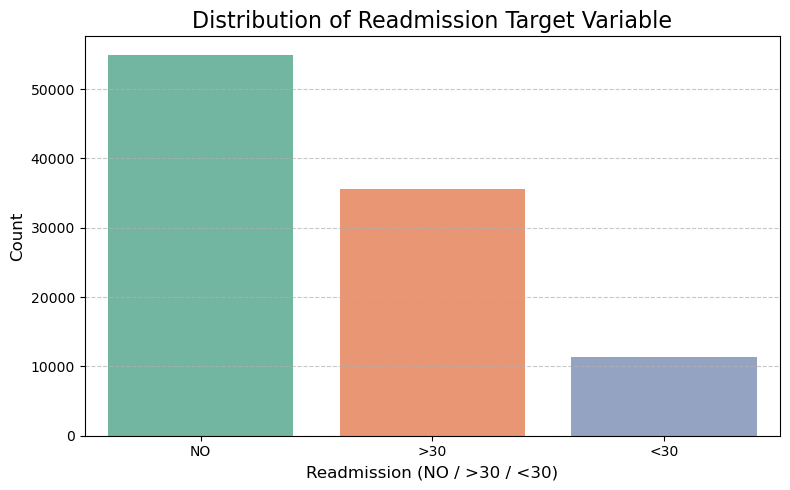

Class distribution:
 readmitted
NO     0.539106
>30    0.349292
<30    0.111602
Name: proportion, dtype: float64


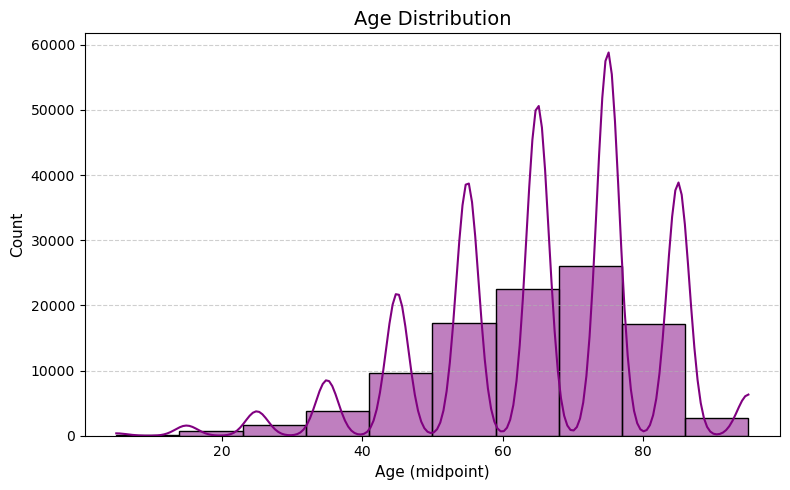

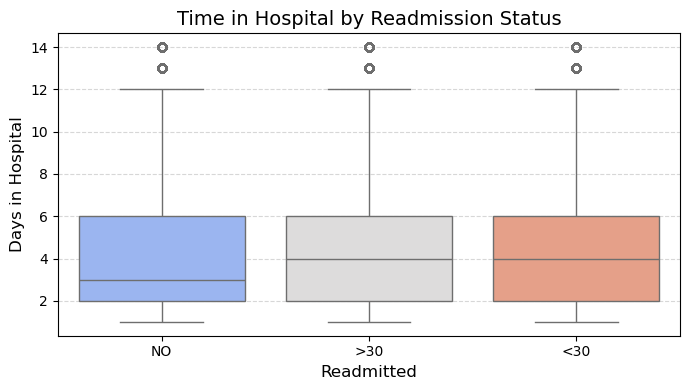

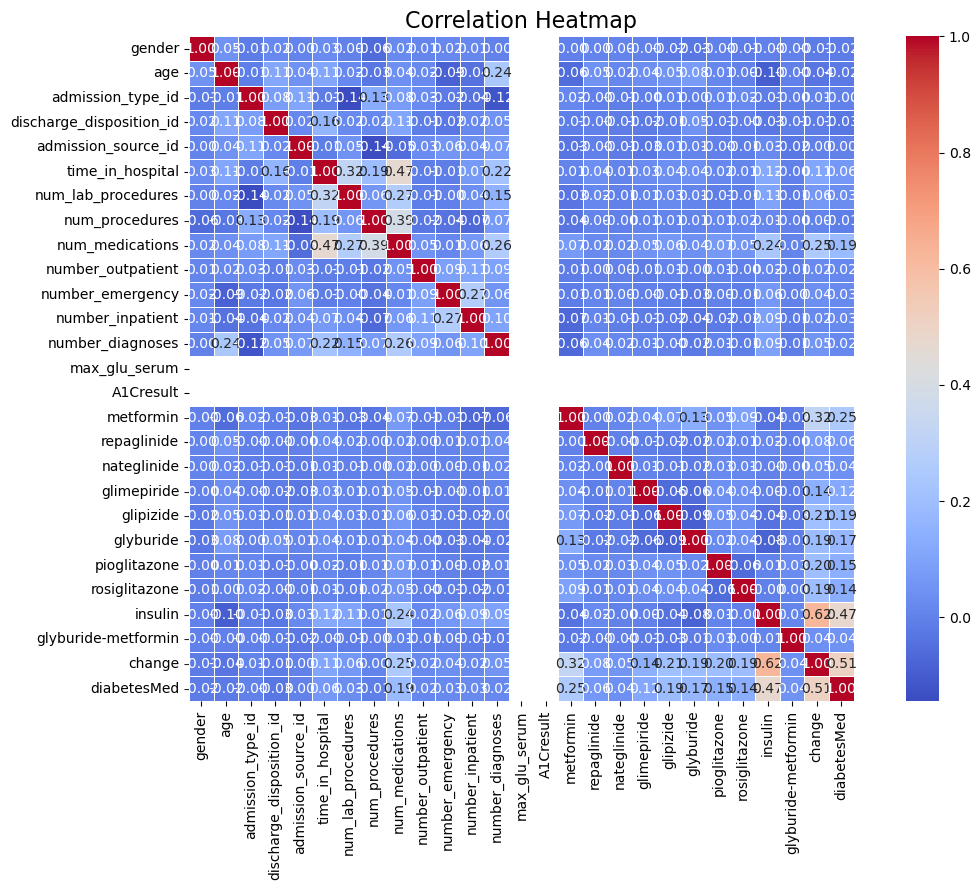

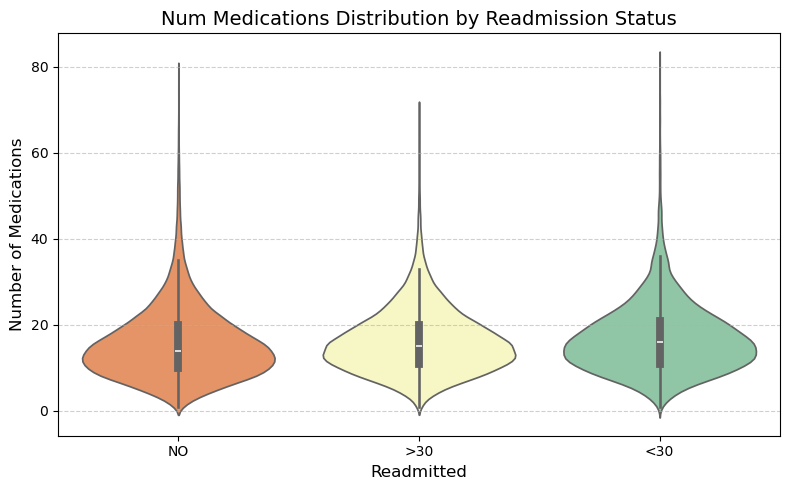

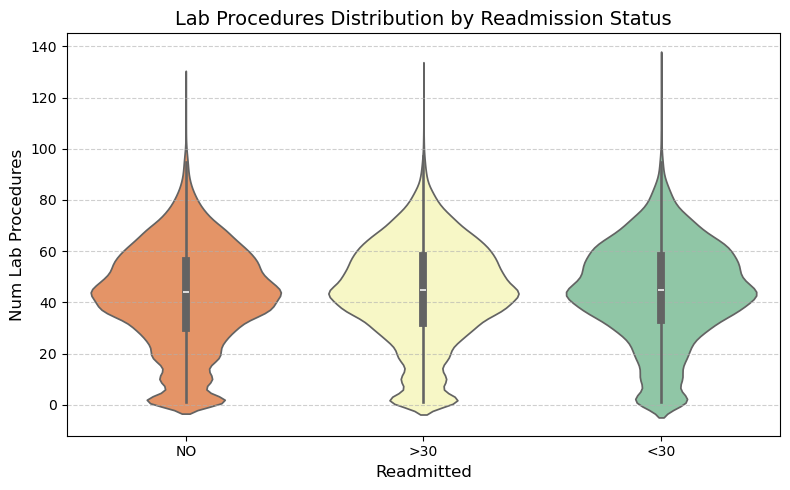

In [15]:
#  Plot 1: Target variable distribution 
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='readmitted', palette='Set2')
plt.title('Distribution of Readmission Target Variable', fontsize=16)
plt.xlabel('Readmission (NO / >30 / <30)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("plot1_target_distribution.png", dpi=150)
plt.show()

print("Class distribution:\n", df['readmitted'].value_counts(normalize=True))

#  Plot 2: Age distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', kde=True, color='purple', bins=10)
plt.title('Age Distribution', fontsize=14)
plt.xlabel('Age (midpoint)', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("plot2_age_distribution.png", dpi=150)
plt.show()

# Plot 3: BMI-equivalent — time_in_hospital by readmission 
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='readmitted', y='time_in_hospital', palette='coolwarm')
plt.title('Time in Hospital by Readmission Status', fontsize=14)
plt.xlabel('Readmitted', fontsize=12)
plt.ylabel('Days in Hospital', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("plot3_time_in_hospital_boxplot.png", dpi=150)
plt.show()

# Plot 4: Correlation heatmap 
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(12, 9))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.savefig("plot4_correlation_heatmap.png", dpi=150)
plt.show()

# Plot 5: Violin — num_medications by readmission 
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='readmitted', y='num_medications', palette='Spectral')
plt.title('Num Medications Distribution by Readmission Status', fontsize=14)
plt.xlabel('Readmitted', fontsize=12)
plt.ylabel('Number of Medications', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("plot5_medications_violin.png", dpi=150)
plt.show()

# Plot 6: Violin — num_lab_procedures by readmission 
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='readmitted', y='num_lab_procedures', palette='Spectral')
plt.title('Lab Procedures Distribution by Readmission Status', fontsize=14)
plt.xlabel('Readmitted', fontsize=12)
plt.ylabel('Num Lab Procedures', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("plot6_lab_procedures_violin.png", dpi=150)
plt.show()

In [7]:
# Select numerical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Univariate stats
print("\nUnivariate statistics:")
print(df[numeric_cols].describe().T)

# Bivariate stats
print("\nMean num_medications by readmitted:")
print(df.groupby('readmitted')['num_medications'].mean())
print("\nMean time_in_hospital by readmitted:")
print(df.groupby('readmitted')['time_in_hospital'].mean())


Univariate statistics:
                             count       mean        std  min   25%   50%  \
gender                    101763.0   0.537602   0.498587  0.0   0.0   1.0   
age                       101763.0  65.966854  15.941022  5.0  55.0  65.0   
admission_type_id         101763.0   2.024017   1.445414  1.0   1.0   1.0   
discharge_disposition_id  101763.0   3.715515   5.279919  1.0   1.0   1.0   
admission_source_id       101763.0   5.754459   4.064110  1.0   1.0   7.0   
time_in_hospital          101763.0   4.396018   2.985092  1.0   2.0   4.0   
num_lab_procedures        101763.0  43.095909  19.674220  1.0  31.0  44.0   
num_procedures            101763.0   1.339691   1.705792  0.0   0.0   1.0   
num_medications           101763.0  16.021835   8.127589  1.0  10.0  15.0   
number_outpatient         101763.0   0.369368   1.267282  0.0   0.0   0.0   
number_emergency          101763.0   0.197842   0.930485  0.0   0.0   0.0   
number_inpatient          101763.0   0.635585   1.26

In [9]:
# STEP 4 — FEATURE ENGINEERING
print("\n" + "=" * 60)
print("STEP 4: FEATURE ENGINEERING")
print("=" * 60)

# New feature 1: total healthcare utilisation across all settings
df['total_utilization'] = (df['number_outpatient']
                           + df['number_emergency']
                           + df['number_inpatient'])
print("Created 'total_utilization'")

# New feature 2: medication load relative to procedures
df['med_procedure_ratio'] = df['num_medications'] / (df['num_procedures'] + 1)
print("Created 'med_procedure_ratio'")


STEP 4: FEATURE ENGINEERING
Created 'total_utilization'
Created 'med_procedure_ratio'



STEP 5: TARGET ENCODING & TRAIN / TEST SPLIT
Class counts:
 readmitted
0    90406
1    11357
Name: count, dtype: int64

Train size : (81410, 29)
Test  size : (20353, 29)

STEP 6: FEATURE SELECTION (Embedded — RF Importances)
Feature Importances:

num_lab_procedures          0.145551
med_procedure_ratio         0.113848
num_medications             0.102544
time_in_hospital            0.079273
age                         0.067163
number_diagnoses            0.053359
discharge_disposition_id    0.048413
num_procedures              0.042667
admission_type_id           0.038850
total_utilization           0.034621
insulin                     0.033687
admission_source_id         0.033156
number_inpatient            0.032400
gender                      0.026190
number_outpatient           0.017885
metformin                   0.017370
glipizide                   0.017187
number_emergency            0.015560
change                      0.014913
glyburide                   0.014492
pioglitazone

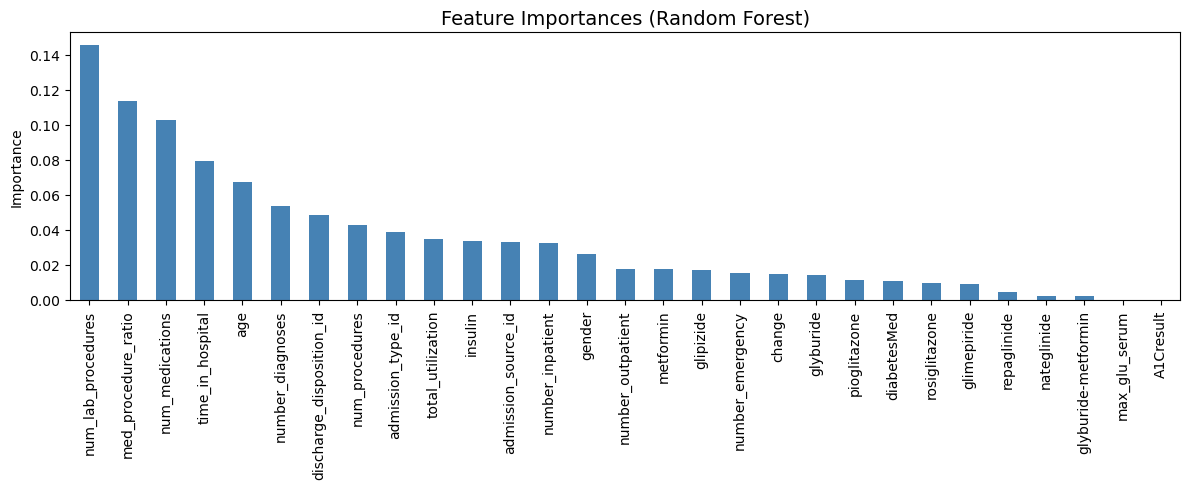


Selected top-10 features: ['num_lab_procedures', 'med_procedure_ratio', 'num_medications', 'time_in_hospital', 'age', 'number_diagnoses', 'discharge_disposition_id', 'num_procedures', 'admission_type_id', 'total_utilization']

STEP 7: STANDARD SCALING
Scaled train shape: (81410, 10)
Scaled test  shape: (20353, 10)


In [10]:
# STEP 5 — DEFINE TARGET & SPLIT
print("\n" + "=" * 60)
print("STEP 5: TARGET ENCODING & TRAIN / TEST SPLIT")
print("=" * 60)

# Binary target: 1 = readmitted within 30 days (<30), 0 = otherwise
y = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)
X = df.drop('readmitted', axis=1)

print("Class counts:\n", y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"\nTrain size : {X_train.shape}")
print(f"Test  size : {X_test.shape}")

# STEP 6 — FEATURE SELECTION (Embedded method — Random Forest importances)
print("\n" + "=" * 60)
print("STEP 6: FEATURE SELECTION (Embedded — RF Importances)")
print("=" * 60)

_rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
_rf_selector.fit(X_train, y_train)

importances   = _rf_selector.feature_importances_
feature_series = pd.Series(importances, index=X.columns).sort_values(ascending=False)

print("Feature Importances:\n")
print(feature_series)

# Plot 8: Feature importance bar chart 
plt.figure(figsize=(12, 5))
feature_series.plot(kind='bar', color='steelblue')
plt.title('Feature Importances (Random Forest)', fontsize=14)
plt.ylabel('Importance')
plt.tight_layout()
plt.savefig("plot8_feature_importances.png", dpi=150)
plt.show()

# Select top 10 features
top_features = feature_series.head(10).index.tolist()
print("\nSelected top-10 features:", top_features)

X_train_sel = X_train[top_features]
X_test_sel  = X_test[top_features]

# STEP 7 — SCALING (mainly required for Logistic Regression)
print("\n" + "=" * 60)
print("STEP 7: STANDARD SCALING")
print("=" * 60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)   
X_test_scaled  = scaler.transform(X_test_sel)        

# Drop NaN rows after transform (safety)
X_train_df = pd.DataFrame(X_train_scaled, columns=top_features)
X_test_df  = pd.DataFrame(X_test_scaled,  columns=top_features)

X_train_clean = X_train_df.dropna()
X_test_clean  = X_test_df.dropna()
y_train_clean = y_train.iloc[:len(X_train_clean)]
y_test_clean  = y_test.iloc[:len(X_test_clean)]

print("Scaled train shape:", X_train_clean.shape)
print("Scaled test  shape:", X_test_clean.shape)

# List to store model evaluation results
results = []

# SHARED EVALUATION HELPER

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, has_proba=True):
    """Fit, predict, print full metrics, plot confusion matrix & ROC curve."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)

    print(f"\n{'─'*50}")
    print(f"  Model : {name}")
    print(f"{'─'*50}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print("\nClassification Report:\n",
          classification_report(y_te, y_pred, zero_division=0))

    # Confusion matrix
    ConfusionMatrixDisplay.from_predictions(y_te, y_pred, cmap=plt.cm.Blues)
    plt.title(f"{name} — Confusion Matrix")
    plt.tight_layout()
    plt.savefig(f"plot_cm_{name.replace(' ','_')}.png", dpi=150)
    plt.show()

    # ROC curve (only if model supports predict_proba)
    roc_auc_val = None
    if has_proba:
        y_probs = model.predict_proba(X_te)[:, 1]
        fpr, tpr, _ = roc_curve(y_te, y_probs)
        roc_auc_val = auc(fpr, tpr)

        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_val:.2f})", color='royalblue')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve — {name}")
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(f"plot_roc_{name.replace(' ','_')}.png", dpi=150)
        plt.show()

    return {
        'Model': name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1 Score': f1, 'AUC': roc_auc_val,
        'fitted_model': model
    }



MODEL 1: RANDOM FOREST

PARAMETER TUNING — WHY IT MATTERS:
Parameter tuning (hyperparameter optimisation) adjusts a model's settings
before training. Poorly chosen hyperparameters cause underfitting or
overfitting. GridSearchCV systematically tries every combination in a
defined grid and selects the one that maximises a chosen metric (recall
here) using cross-validation, ensuring the best generalisation.

Best RF params  : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best CV Recall  : 0.0118

──────────────────────────────────────────────────
  Model : Random Forest
──────────────────────────────────────────────────
  Accuracy  : 0.8852
  Precision : 0.2481
  Recall    : 0.0141
  F1 Score  : 0.0267

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.99      0.94     18082
           1       0.25      0.01      0.03      2271

    accuracy                           0.89     20353
   macro avg       0.57      

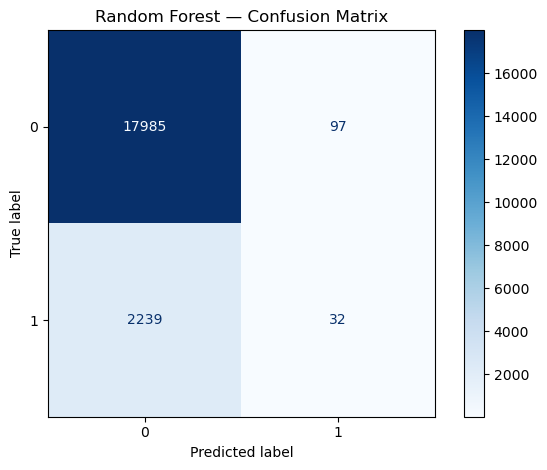

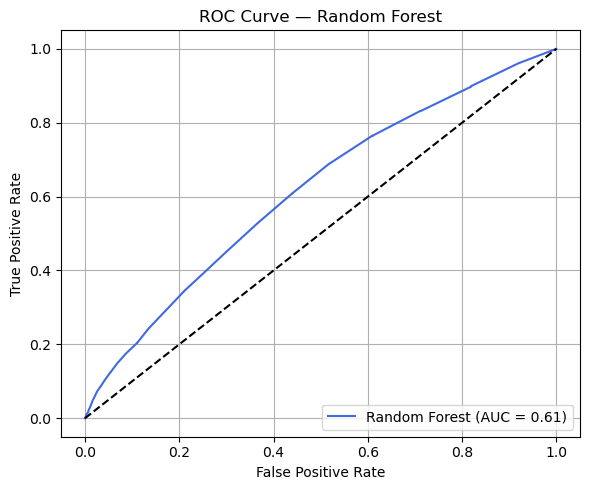

In [11]:
# MODEL 1 — RANDOM FOREST
# GridSearchCV parameter tuning
print("\n" + "=" * 60)
print("MODEL 1: RANDOM FOREST")
print("=" * 60)

print("""
PARAMETER TUNING — WHY IT MATTERS:
Parameter tuning (hyperparameter optimisation) adjusts a model's settings
before training. Poorly chosen hyperparameters cause underfitting or
overfitting. GridSearchCV systematically tries every combination in a
defined grid and selects the one that maximises a chosen metric (recall
here) using cross-validation, ensuring the best generalisation.
""")

rf_param_grid = {
    'n_estimators':     [50, 100, 200],
    'max_depth':        [5, 10, None],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid, cv=3, scoring='recall', n_jobs=-1
)
rf_grid.fit(X_train_clean, y_train_clean)

print("Best RF params  :", rf_grid.best_params_)
print("Best CV Recall  :", f"{rf_grid.best_score_:.4f}")

rf_metrics = evaluate_model(
    "Random Forest",
    rf_grid.best_estimator_,
    X_train_clean, y_train_clean,
    X_test_clean,  y_test_clean
)
results.append(rf_metrics)


MODEL 2: LOGISTIC REGRESSION

VALIDATION — WHY IT MATTERS:
Validation evaluates a model on unseen data to detect overfitting (high
training accuracy but poor test accuracy). Cross-validation (CV) divides
the training set into k folds and rotates the validation fold, giving a
more robust performance estimate than a single train/test split.
The final assessment on the held-out test set confirms generalisation.

Best LR params  : {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Recall  : 0.0029

──────────────────────────────────────────────────
  Model : Logistic Regression
──────────────────────────────────────────────────
  Accuracy  : 0.8878
  Precision : 0.2174
  Recall    : 0.0022
  F1 Score  : 0.0044

Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94     18082
           1       0.22      0.00      0.00      2271

    accuracy                           0.89     20353
   macro avg       0.55      0.5

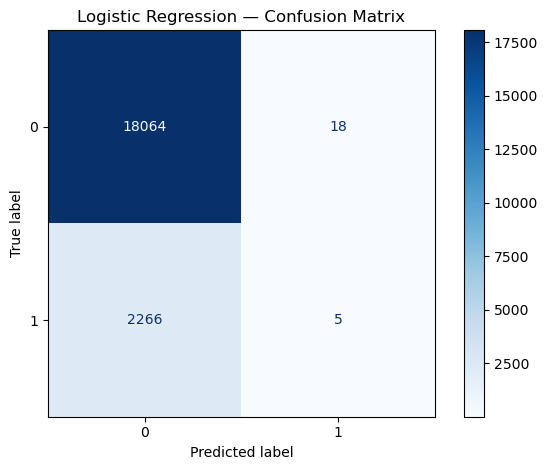

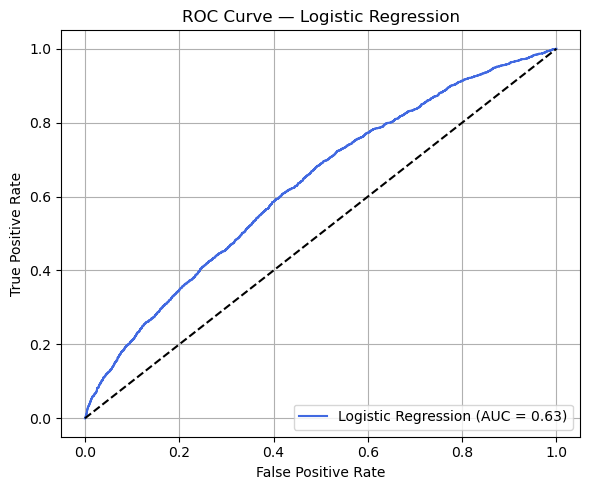

In [12]:
# MODEL 2 — LOGISTIC REGRESSION
# GridSearchCV parameter tun
print("\n" + "=" * 60)
print("MODEL 2: LOGISTIC REGRESSION")
print("=" * 60)

print("""
VALIDATION — WHY IT MATTERS:
Validation evaluates a model on unseen data to detect overfitting (high
training accuracy but poor test accuracy). Cross-validation (CV) divides
the training set into k folds and rotates the validation fold, giving a
more robust performance estimate than a single train/test split.
The final assessment on the held-out test set confirms generalisation.
""")

lr_param_grid = {
    'C':       [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver':  ['liblinear']
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    lr_param_grid, cv=3, scoring='recall', n_jobs=-1
)
lr_grid.fit(X_train_clean, y_train_clean)

print("Best LR params  :", lr_grid.best_params_)
print("Best CV Recall  :", f"{lr_grid.best_score_:.4f}")

lr_metrics = evaluate_model(
    "Logistic Regression",
    lr_grid.best_estimator_,
    X_train_clean, y_train_clean,
    X_test_clean,  y_test_clean
)
results.append(lr_metrics)




MODEL 3: DECISION TREE CLASSIFIER

DECISION TREE — WHY IT IS USED:
Decision Tree is an interpretable supervised machine learning model.
It splits the data into decision rules based on feature values, making it easy
to understand how predictions are made. Here, GridSearchCV is used to tune the
main tree settings and improve recall while reducing overfitting.

Best Decision Tree params: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Recall: 0.1713

──────────────────────────────────────────────────
  Model : Decision Tree
──────────────────────────────────────────────────
  Accuracy  : 0.7890
  Precision : 0.1535
  Recall    : 0.1973
  F1 Score  : 0.1726

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.86      0.88     18082
           1       0.15      0.20      0.17      2271

    accuracy                           0.79     20353
   macro avg       0.52      0.53      0.53   

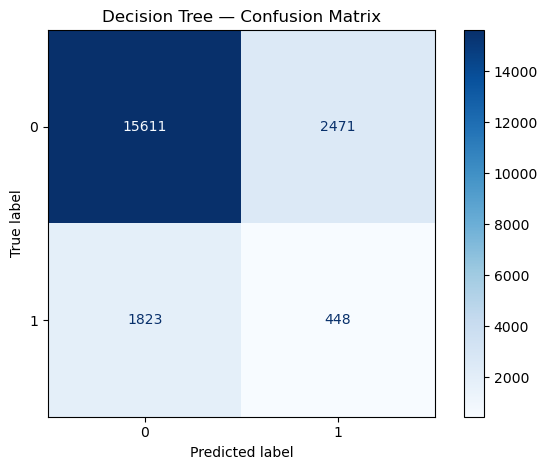

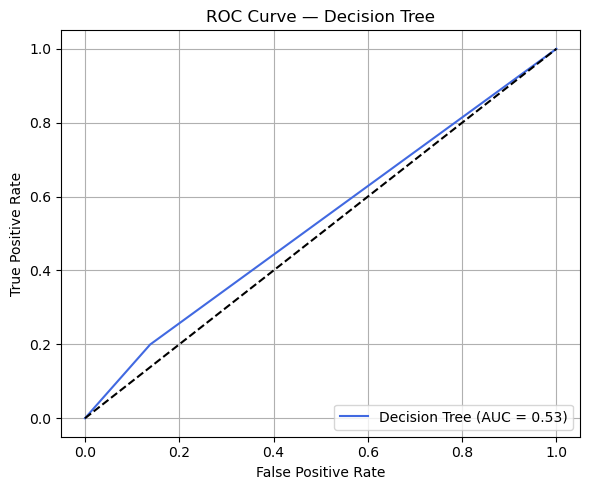

In [13]:
# MODEL 3 — DECISION TREE CLASSIFIER
# GridSearchCV parameter tuning
print("\n" + "=" * 60)
print("MODEL 3: DECISION TREE CLASSIFIER")
print("=" * 60)

print("""
DECISION TREE — WHY IT IS USED:
Decision Tree is an interpretable supervised machine learning model.
It splits the data into decision rules based on feature values, making it easy
to understand how predictions are made. Here, GridSearchCV is used to tune the
main tree settings and improve recall while reducing overfitting.
""")

dt_param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=3,
    scoring='recall',
    n_jobs=-1
)

dt_grid.fit(X_train_clean, y_train_clean)

print("Best Decision Tree params:", dt_grid.best_params_)
print("Best CV Recall:", f"{dt_grid.best_score_:.4f}")

dt_metrics = evaluate_model(
    "Decision Tree",
    dt_grid.best_estimator_,
    X_train_clean, y_train_clean,
    X_test_clean, y_test_clean
)

results.append(dt_metrics)


In [14]:
# Save the tuned Decision Tree model object separately if needed
best_dt = DecisionTreeClassifier(
    **dt_grid.best_params_,
    random_state=42
)

best_dt.fit(X_train_clean, y_train_clean)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None



PHASE 3: MODEL COMPARISON & FINAL INSIGHTS

Full Model Comparison:
              Model  Accuracy  Precision   Recall  F1 Score      AUC
      Decision Tree  0.789024   0.153477 0.197270  0.172640 0.530678
      Random Forest  0.885226   0.248062 0.014091  0.026667 0.614631
Logistic Regression  0.887781   0.217391 0.002202  0.004359 0.629660


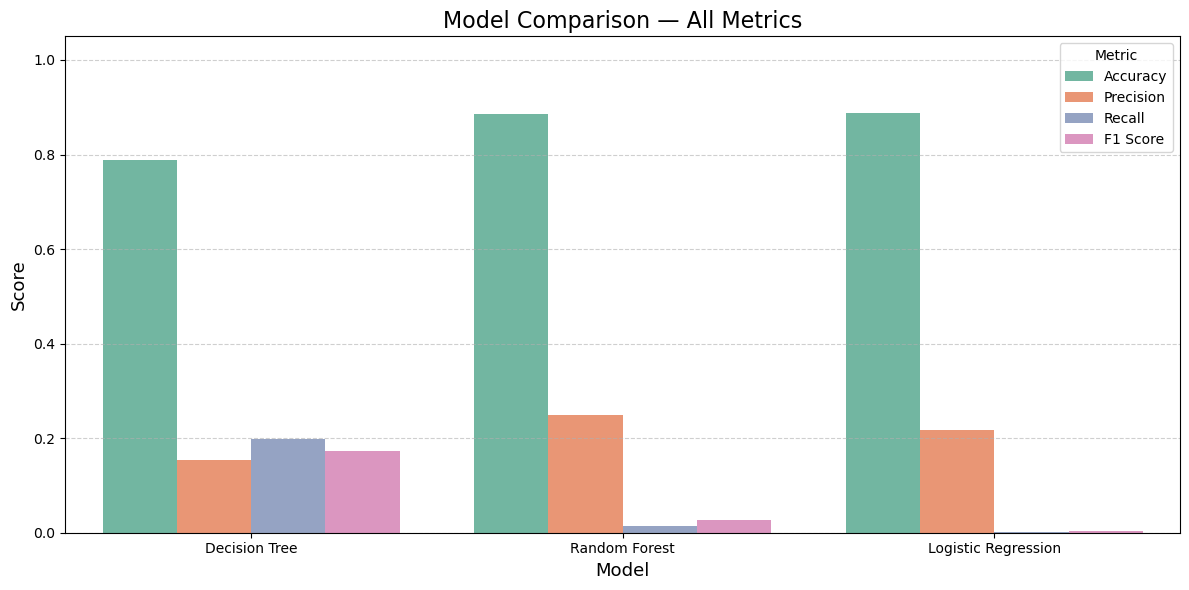


Best model by Recall: Decision Tree
  Recall    : 0.1973
  Precision : 0.1535
  F1 Score  : 0.1726
  AUC       : 0.5307


In [15]:
# PHASE 3 — COMPARISON & FINAL INSIGHTS
print("\n" + "=" * 60)
print("PHASE 3: MODEL COMPARISON & FINAL INSIGHTS")
print("=" * 60)

summary_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'fitted_model'} for r in results
])
summary_df = summary_df.sort_values('Recall', ascending=False).reset_index(drop=True)

print("\nFull Model Comparison:")
print(summary_df.to_string(index=False))

# ── Plot: Summary bar chart ───────────────────────────────────────────────────
df_melted = summary_df.melt(
    id_vars='Model',
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    var_name='Metric', value_name='Score'
)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette='Set2')
plt.title('Model Comparison — All Metrics', fontsize=16)
plt.xlabel('Model', fontsize=13)
plt.ylabel('Score', fontsize=13)
plt.ylim(0, 1.05)
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("plot_model_comparison.png", dpi=150)
plt.show()

# ── Identify best model ───────────────────────────────────────────────────────
best_row       = summary_df.iloc[0]
best_name      = best_row['Model']
best_obj       = next(r['fitted_model'] for r in results if r['Model'] == best_name)

print(f"\nBest model by Recall: {best_name}")
print(f"  Recall    : {best_row['Recall']:.4f}")
print(f"  Precision : {best_row['Precision']:.4f}")
print(f"  F1 Score  : {best_row['F1 Score']:.4f}")
print(f"  AUC       : {best_row['AUC']:.4f}")


── Cross-Validation (5-fold) on Decision Tree ──
CV Recall scores : [0.1723 0.1607 0.1695 0.1695 0.1837]
Mean CV Recall   : 0.1711 ± 0.0074


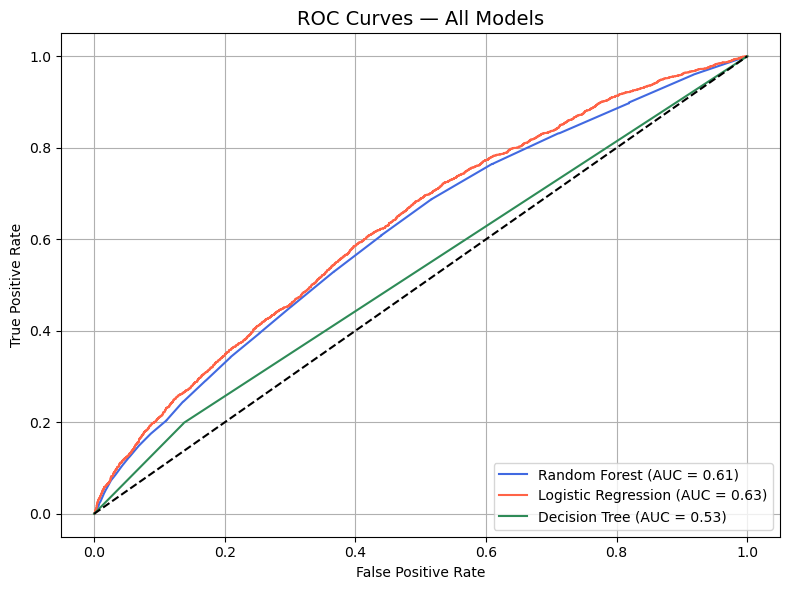

In [16]:
# ── Cross-validation on best model ───────────────────────────────────────────
print(f"\n── Cross-Validation (5-fold) on {best_name} ──")
cv_scores = cross_val_score(
    best_obj, X_train_clean, y_train_clean, cv=5, scoring='recall'
)
print(f"CV Recall scores : {np.round(cv_scores, 4)}")
print(f"Mean CV Recall   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# ── Overlay ROC curves for all three models ───────────────────────────────────
plt.figure(figsize=(8, 6))
colors = ['royalblue', 'tomato', 'seagreen']
for res, color in zip(results, colors):
    mdl    = res['fitted_model']
    y_prob = mdl.predict_proba(X_test_clean)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_clean, y_prob)
    roc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{res['Model']} (AUC = {roc_val:.2f})", color=color)

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models", fontsize=14)
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig("plot_roc_all_models.png", dpi=150)
plt.show()
